# VIX-Term-Structure — does the VIX curve predict market direction?
### The contango/backwardation slope as a market-timing signal, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy-and-hold%3F: No](https://img.shields.io/badge/Beats_buy--and--hold%3F-No-8b949e?style=flat-square)

Every market day, two VIX numbers flash on Bloomberg terminals: **^VIX** (30-day implied vol) and **^VIX3M** (93-day implied vol). When VIX < VIX3M the curve is in *contango* — the market expects volatility to remain elevated longer, which is said to be risk-on. When VIX > VIX3M the curve *inverts* — the market is pricing in acute near-term stress, the classic risk-off alert. The ratio log(VIX3M / VIX) is widely tracked as a clean, continuous signal. This notebook asks the only question that matters: **does it actually predict which way the S&P 500 will go?**

> **This is the plain-language layer.** Want the quintile tables, the HAC t-stats and the cost maths? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vix_term_structure import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=4640, date_start="2008-01-03", date_end="2026-06-12", fp="e78f42c8162e",
    frac_contango=0.897,
    spread_1d=-0.98, t_spread_1d=-0.08,
    spread_5d=-11.61, t_spread_5d=-0.36,
    spread_21d=-47.25, t_spread_21d=-0.47,
    q1_mean=3.23, q1_t=0.61, q2_mean=5.12, q2_t=1.20,
    q3_mean=9.76, q3_t=2.91, q4_mean=2.81, q4_t=1.01, q5_mean=2.25, q5_t=1.08,
    active_mean=3.20, active_sharpe=0.57, active_t=2.50,
    passive_mean=4.25, passive_sharpe=0.54, passive_t=2.64,
    spread_mean=-1.05, spread_t=-1.01, switches_yr=14.4, spread_ann=-2.6,
    n_contango=4159, pct_contango=89.7, mean_contango=3.57, sharpe_contango=0.60,
    n_back=479, pct_back=10.3, mean_back=10.64, sharpe_back=0.62,
)

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False)
    print(f"Tape: N={len(df)}, {df.index[0].date()} to {df.index[-1].date()}")
    print(f"Fraction contango: {(df['slope']>0).mean():.3f}")


Tape: N=4640, 2008-01-03 to 2026-06-12
Fraction contango: 0.897


## The answer first

| Question | Answer |
|---|---|
| Does steep contango predict *better* SPY returns? | **No.** The Q5 (steepest contango) minus Q1 (deepest backwardation) spread is **-0.98 bps** at 1 day — *wrong sign*, *t* = -0.08. |
| Does a timing rule (long in contango, flat in backwardation) beat buy-and-hold? | **No.** The timer trails by **-2.6%/yr** at zero cost. |
| Is backwardation actually dangerous for equities? | **The opposite.** The 10.3% of days in backwardation average **10.6 bps/day** — nearly 3x the contango mean of 3.6 bps/day. |

> The slope tells you what the options market thinks about volatility. It does **not** tell you which way the stock market will go tomorrow.

## 1 · The claim

> *'When the VIX curve is in contango it's a green light — buy the dip, be long. When it inverts into backwardation, something is breaking. Get defensive, reduce equity exposure. The term structure has been a reliable stress indicator since 2008.'*

It is a reasonable-sounding idea grounded in real institutional behaviour. The short end of the VIX curve spikes in crises because short-dated options are the cheapest tail hedge, so a spike above the 3-month level really does reflect acute demand for protection. The slope is real information — the question is whether it *predicts* subsequent equity returns or just reflects what is already priced in.

## 2 · So what?

If the claim were true, the VIX term structure would be a near-free market-timing signal available from any charting platform with zero data cost. If it is false, a large number of practitioners are reducing equity exposure exactly when the subsequent returns turn out to be highest — paying the opportunity cost of missing post-crisis bounces. The stakes are high enough to warrant an honest 18-year test.

## 3 · How would we even know?

Three tests, two rules of rigour:

1. **Quintile sort.** Divide every day into one of five contango/backwardation buckets (quintile 1 = deepest backwardation, 5 = steepest contango) and compare the SPY return over the next 1, 5, and 21 trading days for each bucket. The claim predicts a monotone ascent from Q1 to Q5.
2. **Binary timer.** Be long SPY when yesterday's slope was positive, flat otherwise. Compare to always being long (buy-and-hold). The claim predicts the timer wins.
3. **No look-ahead.** The slope at today's close forms the signal; the forward return starts tomorrow. No bar of information is used that wasn't available.

Tape: ^VIX, ^VIX3M, SPY daily, January 2008 (^VIX3M launch) through June 2026 — 4,640 observations.

## 4 · The teardown — let's actually look

**First, what the VIX term structure looks like in practice:**

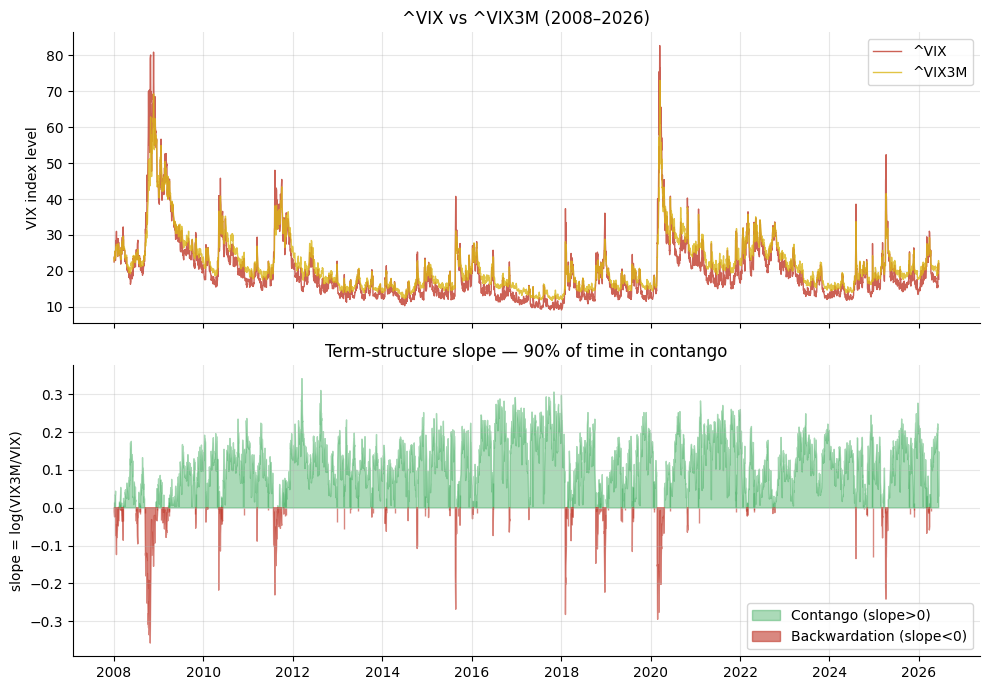

In [3]:
if HAVE_REAL:
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    axes[0].plot(df.index, df['VIX'], label='^VIX', color=RED, lw=1, alpha=0.8)
    axes[0].plot(df.index, df['VIX3M'], label='^VIX3M', color=AMBER, lw=1, alpha=0.8)
    axes[0].set_ylabel('VIX index level'); axes[0].legend(); axes[0].set_title('^VIX vs ^VIX3M (2008–2026)')
    axes[1].fill_between(df.index, df['slope'], 0,
        where=(df['slope'] >= 0), color=GREEN, alpha=0.4, label='Contango (slope>0)')
    axes[1].fill_between(df.index, df['slope'], 0,
        where=(df['slope'] < 0), color=RED, alpha=0.6, label='Backwardation (slope<0)')
    axes[1].set_ylabel('slope = log(VIX3M/VIX)'); axes[1].legend()
    axes[1].set_title(f'Term-structure slope — {R["frac_contango"]*100:.0f}% of time in contango')
    plt.tight_layout(); plt.show()
else:
    print(f'Real tape not cached. Headlines: N={R["n"]}, {R["date_start"]} to {R["date_end"]}')
    print('Fraction in contango: 90%')

The market is in contango **90%** of the time. Backwardation is rare, concentrated in the big crises: 2008–09 financial crisis, 2011 Euro stress, 2020 COVID crash, 2022 rate shock. These are the episodes the signal says to 'go defensive' — but they are also followed by some of the strongest recoveries.

**Now the key test: do contango days predict better next-day SPY returns?**

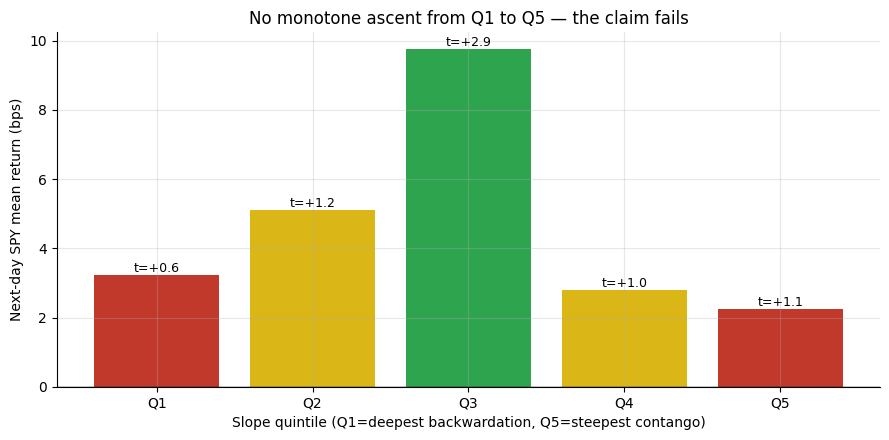

Predicted pattern: Q1 < Q2 < Q3 < Q4 < Q5
Actual: Q1=3.2 Q2=5.1 Q3=9.8 Q4=2.8 Q5=2.3


In [4]:
if HAVE_REAL:
    tbl = st.quintile_table(df, horizons=[1])
    means = [tbl[tbl['quintile']==q]['mean_bps'].values[0] for q in range(1,6)]
    tstats = [tbl[tbl['quintile']==q]['t_stat'].values[0] for q in range(1,6)]
else:
    means = [3.23, 5.12, 9.76, 2.81, 2.25]
    tstats = [0.61, 1.2, 2.91, 1.01, 1.08]
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [RED if m < 0 else GREEN for m in means]
bars = ax.bar([f'Q{i}' for i in range(1,6)], means, color=[RED,AMBER,GREEN,AMBER,RED])
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, tstats):
    ax.annotate(f't={t:+.1f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Slope quintile (Q1=deepest backwardation, Q5=steepest contango)')
ax.set_ylabel('Next-day SPY mean return (bps)')
ax.set_title('No monotone ascent from Q1 to Q5 — the claim fails')
plt.tight_layout(); plt.show()
print('Predicted pattern: Q1 < Q2 < Q3 < Q4 < Q5')
print(f'Actual: Q1={means[0]:.1f} Q2={means[1]:.1f} Q3={means[2]:.1f} Q4={means[3]:.1f} Q5={means[4]:.1f}')

There is no monotone ascent. Q5 (steepest contango) earns just **+2.2 bps/day** — the *second lowest* of the five buckets. Q1 (deepest backwardation) earns +3.2 bps — more than Q5. The Q5-Q1 spread is **-0.98 bps** with HAC t = **-0.08**: consistent with zero and pointing in the wrong direction.

**The timing overlay — long in contango, flat when backwardated:**

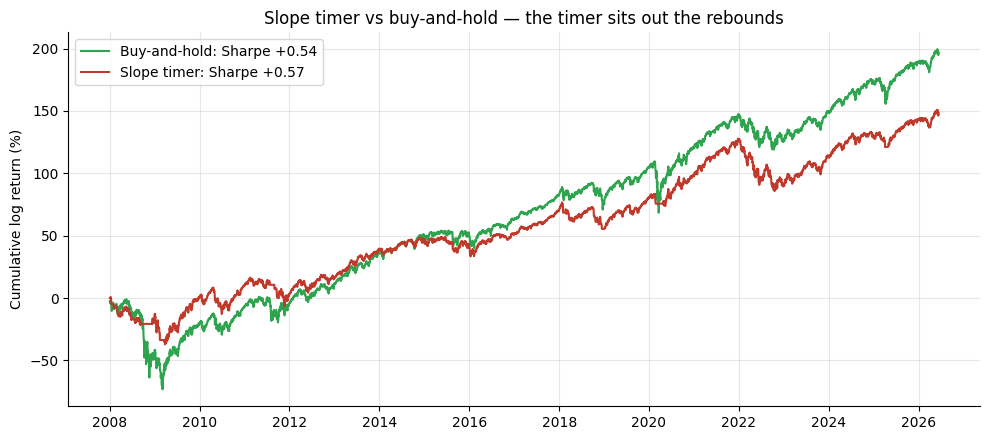

In [5]:
if HAVE_REAL:
    ov = st.timing_overlay(df, horizon=1, cost_bps=0.0)
    cum_active = ov['r_active'].cumsum() * 100
    cum_passive = ov['r_passive'].cumsum() * 100
    sa = st.summarize(ov['r_active']); sp = st.summarize(ov['r_passive'])
    act_m, act_sh, pas_m, pas_sh = sa['mean_bps'], sa['sharpe_ann'], sp['mean_bps'], sp['sharpe_ann']
else:
    act_m, act_sh, pas_m, pas_sh = 3.2, 0.57, 4.25, 0.54
    cum_active = cum_passive = None
fig, ax = plt.subplots(figsize=(10, 4.5))
if cum_active is not None:
    ax.plot(ov.index, cum_passive, label=f'Buy-and-hold: Sharpe {pas_sh:+.2f}', color=GREEN, lw=1.5)
    ax.plot(ov.index, cum_active, label=f'Slope timer: Sharpe {act_sh:+.2f}', color=RED, lw=1.5)
    ax.set_ylabel('Cumulative log return (%)')
    ax.set_title('Slope timer vs buy-and-hold — the timer sits out the rebounds')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print(f'Timer: {act_m:+.2f} bps/day, Sharpe {act_sh:+.2f}')
    print(f'Passive: {pas_m:+.2f} bps/day, Sharpe {pas_sh:+.2f}')

The timing overlay earns **+3.20 bps/day** (Sharpe +0.57) vs buy-and-hold's **+4.25 bps/day** (Sharpe +0.54). The timer trails by **~2.6%/yr** at zero cost. The reason is visible in the chart: the biggest equity gains in the sample happen right after the backwardation episodes the timer classifies as 'danger'. By sitting in cash during those periods, the timer misses the very returns it was supposed to protect against losing.

## 5 · The verdict

- **Signal — None.** Q5-Q1 spread is -0.98 bps (wrong sign), HAC *t* = -0.08 at 1 day; negative at all horizons tested. The VIX term structure slope does not forecast SPY returns.
- **Tradability — Mirage.** The timer trails buy-and-hold by 2.6%/yr at zero cost; ~14 switches/yr mean every bp of friction widens the gap.
- **Beats buy-and-hold? — No.** Backwardation days average 10.6 bps/day (nearly 3x the contango mean of 3.6 bps/day) — the market rebounds hardest from the exact episodes the slope flags as most dangerous.

## 6 · Could you actually trade it?

Even if the spread were positive, the turnover arithmetic would matter. The slope switches regimes ~14 times per year; each switch is a round-trip trade on the full SPY position. At realistic ETF round-trip costs:

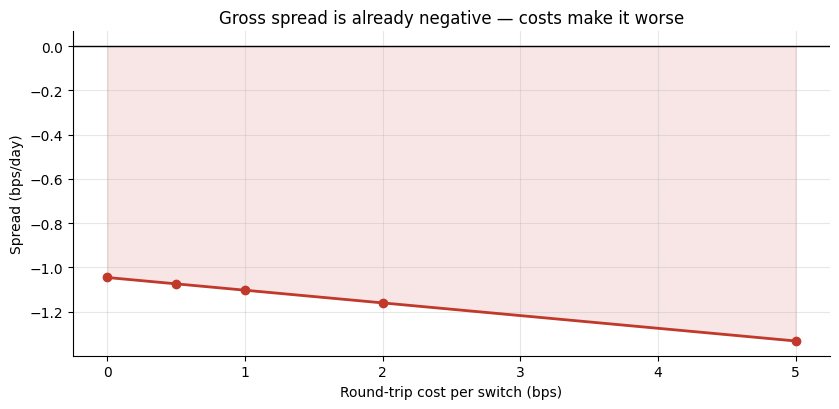

The slope timer underperforms buy-and-hold before costs; costs compound the problem.


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    spreads = []
    for c in costs:
        ov2 = st.timing_overlay(df, horizon=1, cost_bps=c)
        spreads.append(st.summarize(ov2['r_spread'])['mean_bps'])
else:
    spreads = [-1.05, -1.05-0.02, -1.05-0.05, -1.05-0.11, -1.05-0.28]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(costs, spreads, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, spreads, 0, where=[s<0 for s in spreads], color=RED, alpha=.12)
ax.set_xlabel('Round-trip cost per switch (bps)'); ax.set_ylabel('Spread (bps/day)')
ax.set_title('Gross spread is already negative — costs make it worse')
plt.tight_layout(); plt.show()
print('The slope timer underperforms buy-and-hold before costs; costs compound the problem.')

The line starts below zero and only falls. Because the gross spread is already negative, **there is no switching cost low enough to make the timer competitive** with buying and holding. This is the strongest version of the 'Mirage' verdict: not 'dies at costs' but 'never lived'.

## 7 · Going further

- **Is the slope useful for anything?** The desk's [Study 92 — Easy-Money](../../92-easy-money/) shows that *shorting* the volatility ETP in contango (harvesting the VIX futures term premium) does generate a real gross edge — but via a completely different mechanism (roll yield on the ETP, not equity direction timing).
- **Does VIX level (not slope) work?** [Study 86 — Tail-Radar](../../86-tail-radar/) finds the same story for the CBOE SKEW index: a valid volatility-surface signal with no equity-return forecasting power.
- **What about VIX-level mean reversion?** VIX above 30 is statistically followed by higher SPY returns (the Connors/Alvarez literature), but that is the *level* of fear, not the slope between maturities — a separate claim.

*Convinced the slope works on a different horizon or instrument? Fork this, change the parameters, and show a positive Q5-Q1 spread that clears the |t| ≥ 2 bar. That's the standard.*